# Redes Adversariales Generativas (GANs)

Las redes adversariales generativas, conocidas como GANs, constituyen una arquitectura revolucionaria de aprendizaje profundo introducida en 2014 por [Ian Goodfellow](https://arxiv.org/pdf/1406.2661.pdf) y colaboradores. Su propósito es entrenar modelos que aprendan a sintetizar datos realistas a partir de conjuntos de entrenamiento, especialmente en la generación de imágenes. Aunque el concepto fundamental es simple, su implementación práctica presentó desafíos significativos durante años. Actualmente, estas redes producen resultados extraordinarios en múltiples aplicaciones:

- Síntesis de rostros: https://www.thispersondoesnotexist.com/
- Generación de propiedades inmobiliarias: https://thisrentaldoesnotexist.com/
- Mejora de resolución: https://www.youtube.com/watch?v=3RYNThid23g
- Restauración de imágenes a color: https://github.com/jantic/DeOldify
- Creación de escenas naturales: http://nvidia-research-mingyuliu.com/gaugan
- Y muchas aplicaciones más.

## Estructura Fundamental

Las redes GANs se organizan a través de dos componentes neuronales distintos:

- El **generador**: toma como entrada vectores de ruido aleatorio (típicamente muestreados de una distribución gaussiana) y produce como salida imágenes sintéticas. Este vector de entrada puede interpretarse como una representación comprimida o latente de la imagen generada.
- El **discriminador**: recibe imágenes como entrada (ya sean del conjunto de datos real o producidas por el generador) y realiza una clasificación binaria determinando si la imagen pertenece a la categoría real o sintética.

![](https://www.researchgate.net/publication/336781462/figure/fig2/AS:817722363494401@1571971612898/Example-of-a-typical-GANs-architecture-for-both-hand-written-digits-recognition-and.png)

Durante el proceso de aprendizaje, ambas redes entablan una competencia recíproca. El generador busca constantemente mejorar sus producciones para engañar al discriminador, mientras que el discriminador perfecciona su capacidad de discernimiento entre imágenes auténticas e imágenes fabricadas artificialmente. Este escenario competitivo requiere un procedimiento de entrenamiento especializado, diferente al empleado en redes convencionales. El objetivo es alcanzar un generador de tal calidad que el discriminador sea incapaz de distinguir entre imágenes reales y falsas. Esta condición impone restricciones rigurosas en el protocolo de entrenamiento, requiriendo un enfoque meticuloso para lograrse exitosamente.

## Procedimiento de Entrenamiento

El proceso de aprendizaje de una GAN se estructura en dos fases coordinadas:

1. **Fase del discriminador**: En cada paso iterativo, entrenamos al discriminador presentándole un lote mixto de imágenes auténticas del conjunto de datos e imágenes falsas generadas por el generador. Asignamos etiquetas binarias: 0 para las imágenes sintéticas y 1 para las auténticas. Aplicamos una función de pérdida de entropía cruzada binaria para refinar el discriminador, mejorando así su habilidad para diferenciar genuinas de fabricadas.
2. **Fase del generador**: Después, entrenamos el generador alimentándolo con vectores de ruido aleatorio para que produzca imágenes. Estas imágenes sintéticas se introducen en el discriminador, y sus predicciones (clasificación real/falso) se comparan con etiquetas que indican que las imágenes son reales. Utilizamos la misma función de pérdida para actualizar el generador, permitiendo que ajuste sus parámetros para generar imágenes cada vez más convincentes.

## Implementación: GAN Elemental con STL-10

Demostraremos cómo construir e implementar esta arquitectura junto con su procedimiento de entrenamiento usando una GAN fundamental para generar imágenes del dataset STL-10 a resolución 96x96 píxeles.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [5]:
import numpy as np
import os
import scipy.io
from PIL import Image
from torchvision import transforms

class STL10Dataset(torch.utils.data.Dataset):
  def __init__(self, root_path, mat_file='train.mat', image_size=96):
    self.images = []
    self.labels = []
    self.class_names = []
    
    mat_path = os.path.join(root_path, mat_file)
    if os.path.exists(mat_path):
      mat_data = scipy.io.loadmat(mat_path)
      X = mat_data['X']  
      N = X.shape[0]
      X_reshaped = X.reshape(N, 96, 96, 3, order='F')
      X_reshaped = np.transpose(X_reshaped, (0, 3, 1, 2))
      X_reshaped = X_reshaped.astype(np.float32) / 255.0 * 2 - 1
      self.images = np.transpose(X_reshaped, (0, 2, 3, 1))
      
      self.labels = mat_data['y'].flatten() - 1
      
      if 'class_names' in mat_data:
        class_names_raw = mat_data['class_names'][0] 
        self.class_names = [str(name[0]) for name in class_names_raw]  
      else:
        self.class_names = [f'class_{i}' for i in range(10)]
      
      print(f"Dataset MATLAB cargado desde {mat_file}:")
      print(f"  - {len(self.images)} imágenes de shape {self.images.shape}")
      print(f"  - Clases: {self.class_names}")
    else:
      raise ValueError(f"No se encontró {mat_path}")

  def __len__(self):
    return len(self.images)

  def __getitem__(self, ix):
    img = torch.from_numpy(self.images[ix]).permute(2, 0, 1).float()
    return img, self.labels[ix]

In [6]:
train = STL10Dataset('./stl10_matlab', mat_file='train.mat', image_size=96)

Dataset MATLAB cargado desde train.mat:
  - 5000 imágenes de shape (5000, 96, 96, 3)
  - Clases: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [7]:
img, label = train[0]
img.shape, img.dtype, img.max(), img.min()

(torch.Size([3, 96, 96]), torch.float32, tensor(1.), tensor(-1.))

In [8]:
dataloader = torch.utils.data.DataLoader(train, batch_size=128, shuffle=True)

imgs, labels = next(iter(dataloader))
imgs.shape, labels.shape


(torch.Size([128, 3, 96, 96]), torch.Size([128]))

El conjunto de datos STL-10 consta de imágenes naturales de 96×96 píxeles a color (RGB) en formato MATLAB, clasificadas en 10 categorías (avión, pájaro, automóvil, gato, venado, perro, caballo, mono, barco, camión).

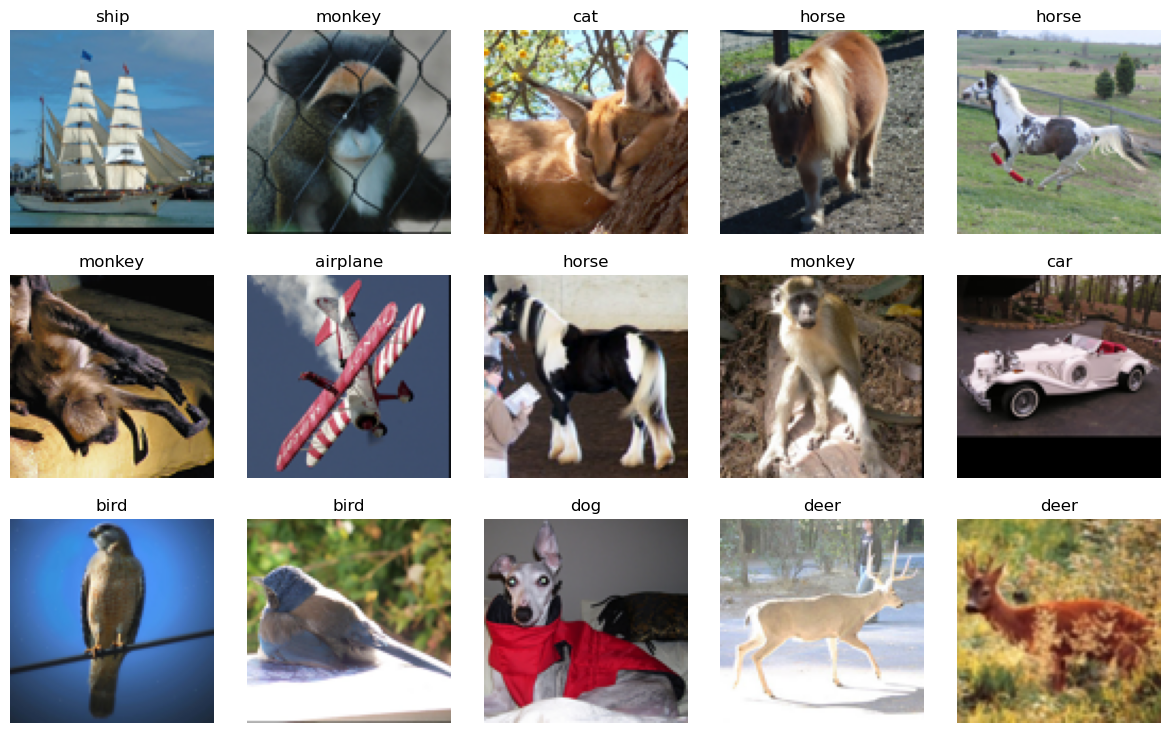

In [9]:
import random
import matplotlib.pyplot as plt

class_names = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

r, c = 3, 5
plt.figure(figsize=(c*3, r*3))
for row in range(r):
    for col in range(c):
        index = c*row + col
        plt.subplot(r, c, index + 1)
        ix = random.randint(0, len(train)-1)
        img, label = train[ix]
        img_show = (img + 1) / 2
        plt.imshow(img_show.permute(1, 2, 0).cpu())
        plt.axis('off')
        label_idx = int(label) if isinstance(label, torch.Tensor) else label
        plt.title(class_names[label_idx])
plt.subplots_adjust(wspace=0.1, hspace=0.2)
plt.show()

El objetivo es entrenar una GAN que sintetice imágenes similares a las del conjunto de datos a partir de vectores de ruido aleatorio. Para esto necesitamos un **generador** y un **discriminador**. Empezaremos con una arquitectura fundamental usando Perceptrón Multicapa (MLP) para ambas redes antes de pasar a arquitecturas más avanzadas.

In [10]:
import torch.nn as nn

def block(n_in, n_out):
  return nn.Sequential(
      nn.Linear(n_in, n_out),
      nn.BatchNorm1d(n_out),
      nn.LeakyReLU(0.2, inplace=True)
  )

class MLP(nn.Module):
  def __init__(self, input_size, output_size):
    super().__init__()
    self.input_size = input_size
    self.fc1 = block(input_size, 512)
    self.fc2 = block(512, 256)
    self.fc3 = nn.Linear(256, output_size)

  def forward(self, x):
    x = self.fc1(x)
    x = self.fc2(x)
    x = self.fc3(x)
    return x


In [11]:
MLP


__main__.MLP

Nuestra arquitectura MLP se compone de tres capas densas conectadas (cada una seguida de activación ReLU). Según el número de entradas y salidas, definimos los distintos modelos. Por ejemplo, el generador recibirá un vector de 100 valores aleatorios y producirá como salida un tensor de 120x120x3 elementos (equivalentes a una imagen del conjunto de datos).

In [12]:
n_in, n_out = 100, 96*96*3
generator = MLP(n_in, n_out).to(device)


In [13]:
output = generator(torch.randn(64, 100).to(device))
output.shape


torch.Size([64, 27648])

Obviamente, nuestro generador inicializado genera imágenes aleatorias que en nada se parecen a las reales.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6168542..1.4664937].


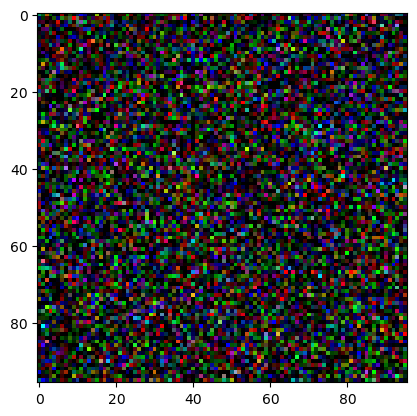

In [14]:
plt.imshow(output[0].reshape(3, 96, 96).permute(1, 2, 0).detach().cpu())
plt.show()


El discriminador, por otro lado, recibirá a la entrada una imagen (96 x 96 valores) y a la salida nos dará una clasificación binaria (real o falso).

In [15]:
discriminator = MLP(96*96*3, 1).to(device)
output = discriminator(torch.randn(64, 96*96*3).to(device))
output.shape


torch.Size([64, 1])

In [16]:
from fastprogress import master_bar, progress_bar

def fit(g, d, dataloader, epochs=30, crit=None):
  g.to(device)
  d.to(device)
  lr_gen  = 2e-4
  lr_disc = 2e-4                         
  g_optimizer = torch.optim.Adam(g.parameters(), lr=lr_gen,  betas=(0.5, 0.999))
  d_optimizer = torch.optim.Adam(d.parameters(), lr=lr_disc, betas=(0.5, 0.999))
  crit = nn.BCEWithLogitsLoss() if crit is None else crit
  g_loss, d_loss = [], []
  mb = master_bar(range(1, epochs+1))
  hist = {'g_loss': [], 'd_loss': []}

  for epoch in mb:
    for X, y in progress_bar(dataloader, parent=mb):
      X      = X.to(device)
      X_flat = X.view(X.size(0), -1)
      batch_size = X.size(0)

      g.eval(); d.train()
      noise            = torch.randn((batch_size, g.input_size)).to(device)
      generated_images = g(noise).detach()
      d_input = torch.cat([generated_images, X_flat])
      d_gt    = torch.cat([
          torch.zeros(batch_size, 1),
          torch.full((batch_size, 1), 0.9)  
      ]).to(device)

      d_optimizer.zero_grad()
      d_l = crit(d(d_input), d_gt)
      d_l.backward()
      torch.nn.utils.clip_grad_norm_(d.parameters(), 1.0)
      d_optimizer.step()
      d_loss.append(d_l.item())

      g.train(); d.eval()
      noise            = torch.randn((batch_size, g.input_size)).to(device)
      generated_images = g(noise)
      g_gt  = torch.ones(batch_size, 1).to(device)

      g_optimizer.zero_grad()
      g_l = crit(d(generated_images), g_gt)
      g_l.backward()
      torch.nn.utils.clip_grad_norm_(g.parameters(), 1.0)
      g_optimizer.step()
      g_loss.append(g_l.item())

      mb.child.comment = f'g_loss {np.mean(g_loss[-100:]):.5f} d_loss {np.mean(d_loss[-100:]):.5f}'

    epoch_g_loss = np.mean(g_loss[-100:])
    epoch_d_loss = np.mean(d_loss[-100:])
    mb.write(f'Epoch {epoch}/{epochs} g_loss {epoch_g_loss:.5f} d_loss {epoch_d_loss:.5f}')
    hist['g_loss'].append(epoch_g_loss)
    hist['d_loss'].append(epoch_d_loss)
    
    if epoch > 50:
      if epoch_d_loss < 0.05 and epoch_g_loss > 1.0:
        mb.write(f'Early stop: discriminador dominante en época {epoch}')
        break
  return hist

In [18]:
hist = fit(generator, discriminator, dataloader, epochs=150)

<div><p>Epoch 1/150 g_loss 2.71515 d_loss 0.19794</p><p>Epoch 2/150 g_loss 3.56158 d_loss 0.19521</p><p>Epoch 3/150 g_loss 3.48924 d_loss 0.19235</p><p>Epoch 4/150 g_loss 3.56006 d_loss 0.18360</p><p>Epoch 5/150 g_loss 4.17086 d_loss 0.17785</p><p>Epoch 6/150 g_loss 5.14894 d_loss 0.17703</p><p>Epoch 7/150 g_loss 4.51457 d_loss 0.17773</p><p>Epoch 8/150 g_loss 3.98457 d_loss 0.17526</p><p>Epoch 9/150 g_loss 4.20872 d_loss 0.17127</p><p>Epoch 10/150 g_loss 5.43579 d_loss 0.17041</p><p>Epoch 11/150 g_loss 5.80811 d_loss 0.17156</p><p>Epoch 12/150 g_loss 4.33020 d_loss 0.17186</p><p>Epoch 13/150 g_loss 3.34292 d_loss 0.17062</p><p>Epoch 14/150 g_loss 3.85437 d_loss 0.16750</p><p>Epoch 15/150 g_loss 4.88967 d_loss 0.16678</p><p>Epoch 16/150 g_loss 5.89815 d_loss 0.16718</p><p>Epoch 17/150 g_loss 4.48660 d_loss 0.16702</p><p>Epoch 18/150 g_loss 3.47190 d_loss 0.16664</p><p>Epoch 19/150 g_loss 3.95525 d_loss 0.17091</p><p>Epoch 20/150 g_loss 4.56422 d_loss 0.17199</p><p>Epoch 21/150 g_loss 3.64132 d_loss 0.17098</p><p>Epoch 22/150 g_loss 3.60150 d_loss 0.16838</p><p>Epoch 23/150 g_loss 3.46811 d_loss 0.17261</p><p>Epoch 24/150 g_loss 3.81222 d_loss 0.17249</p><p>Epoch 25/150 g_loss 3.77174 d_loss 0.16545</p><p>Epoch 26/150 g_loss 5.40710 d_loss 0.17094</p><p>Epoch 27/150 g_loss 6.67616 d_loss 0.17523</p><p>Epoch 28/150 g_loss 6.60129 d_loss 0.17965</p><p>Epoch 29/150 g_loss 6.82140 d_loss 0.18063</p><p>Epoch 30/150 g_loss 6.92993 d_loss 0.17639</p><p>Epoch 31/150 g_loss 7.29367 d_loss 0.17591</p><p>Epoch 32/150 g_loss 7.02165 d_loss 0.17553</p><p>Epoch 33/150 g_loss 6.68322 d_loss 0.18026</p><p>Epoch 34/150 g_loss 6.50522 d_loss 0.18179</p><p>Epoch 35/150 g_loss 6.75327 d_loss 0.18012</p><p>Epoch 36/150 g_loss 7.15103 d_loss 0.17835</p><p>Epoch 37/150 g_loss 6.90511 d_loss 0.17813</p><p>Epoch 38/150 g_loss 6.72946 d_loss 0.18473</p><p>Epoch 39/150 g_loss 6.78334 d_loss 0.18767</p><p>Epoch 40/150 g_loss 6.29561 d_loss 0.18346</p><p>Epoch 41/150 g_loss 5.86515 d_loss 0.18558</p><p>Epoch 42/150 g_loss 5.47361 d_loss 0.19377</p><p>Epoch 43/150 g_loss 5.31737 d_loss 0.20129</p><p>Epoch 44/150 g_loss 4.90020 d_loss 0.20552</p><p>Epoch 45/150 g_loss 4.25549 d_loss 0.20798</p><p>Epoch 46/150 g_loss 3.93370 d_loss 0.20413</p><p>Epoch 47/150 g_loss 3.69008 d_loss 0.20089</p><p>Epoch 48/150 g_loss 3.42613 d_loss 0.20246</p><p>Epoch 49/150 g_loss 3.39866 d_loss 0.20345</p><p>Epoch 50/150 g_loss 3.22257 d_loss 0.19822</p><p>Epoch 51/150 g_loss 3.40846 d_loss 0.19565</p><p>Epoch 52/150 g_loss 3.10790 d_loss 0.19536</p><p>Epoch 53/150 g_loss 3.24557 d_loss 0.19406</p><p>Epoch 54/150 g_loss 3.01416 d_loss 0.19692</p><p>Epoch 55/150 g_loss 2.92493 d_loss 0.19624</p><p>Epoch 56/150 g_loss 3.10273 d_loss 0.19471</p><p>Epoch 57/150 g_loss 3.44707 d_loss 0.19126</p><p>Epoch 58/150 g_loss 3.74622 d_loss 0.19017</p><p>Epoch 59/150 g_loss 3.80861 d_loss 0.19341</p><p>Epoch 60/150 g_loss 3.64931 d_loss 0.19570</p><p>Epoch 61/150 g_loss 3.63591 d_loss 0.19675</p><p>Epoch 62/150 g_loss 3.70791 d_loss 0.19702</p><p>Epoch 63/150 g_loss 3.65345 d_loss 0.19664</p><p>Epoch 64/150 g_loss 3.55347 d_loss 0.19850</p><p>Epoch 65/150 g_loss 3.41761 d_loss 0.19558</p><p>Epoch 66/150 g_loss 3.36018 d_loss 0.19925</p><p>Epoch 67/150 g_loss 3.32311 d_loss 0.20086</p><p>Epoch 68/150 g_loss 3.31695 d_loss 0.19900</p><p>Epoch 69/150 g_loss 3.74404 d_loss 0.20117</p><p>Epoch 70/150 g_loss 3.94971 d_loss 0.19772</p><p>Epoch 71/150 g_loss 3.90406 d_loss 0.20259</p><p>Epoch 72/150 g_loss 3.39079 d_loss 0.20345</p><p>Epoch 73/150 g_loss 3.34955 d_loss 0.20525</p><p>Epoch 74/150 g_loss 3.75595 d_loss 0.19969</p><p>Epoch 75/150 g_loss 4.18170 d_loss 0.20309</p><p>Epoch 76/150 g_loss 3.76769 d_loss 0.20342</p><p>Epoch 77/150 g_loss 3.18092 d_loss 0.20858</p><p>Epoch 78/150 g_loss 2.84714 d_loss 0.20479</p><p>Epoch 79/150 g_loss 2.95079 d_loss 0.20747</p><p>Epoch 80/150 g_loss 3.13140 d_loss 0.20926</p><p>Epoch 81/150 g_loss 2.83042 d_loss 0.21176</p><p>Epoch 82/150 g_loss 2.76993 d_lo

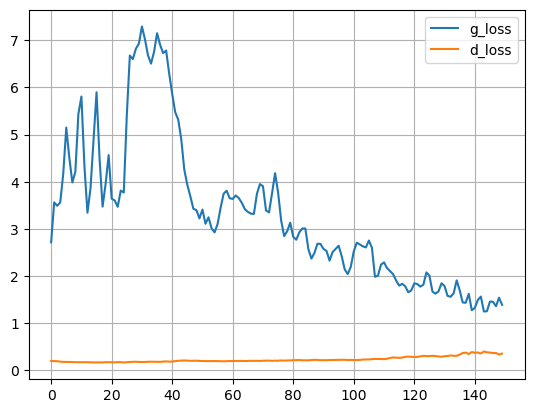

In [19]:
import pandas as pd

df = pd.DataFrame(hist)
df.plot(grid=True)
plt.show()


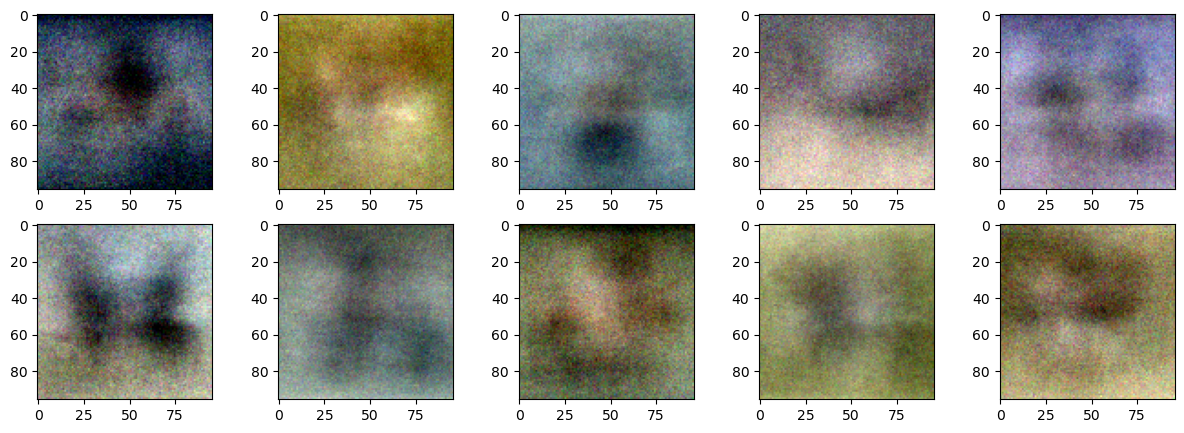

In [20]:
generator.eval()
with torch.no_grad():
  noise = torch.randn((10, generator.input_size)).to(device)
  generated_images = generator(noise)
  fig, axs = plt.subplots(2,5,figsize=(15,5))
  i = 0
  for ax in axs:
    for _ax in ax:
      img = generated_images[i].view(3, 96, 96).permute(1, 2, 0).cpu()
      img = (img + 1) / 2
      _ax.imshow(img.clamp(0, 1))
      i+=1
  plt.show()

Aunque hemos construido correctamente el circuito de entrenamiento de una GAN, nuestro modelo elemental no genera imágenes de calidad satisfactoria. Para lograr resultados superiores se requiere una arquitectura especializada para procesamiento de imágenes: las redes convolucionales.

## Arquitecturas Convolucionales Profundas: DCGANs

Las redes GANs convolucionales profundas (DCGANs) integran arquitecturas convolucionales para lograr generadores de mayor capacidad. En este enfoque, el generador y discriminador requieren diseños especializados distintos.

![](https://gluon.mxnet.io/_images/dcgan.png)

El generador comienza con un vector de 100 valores aleatorios al cual se aplican sucesivamente capas de convolución transpuesta (que expanden progresivamente el tamaño de los mapas de características, similar a técnicas de segmentación semántica) hasta producir la imagen final.


In [43]:
import torch.nn as nn

class Generator(nn.Module):
  def __init__(self):
    super().__init__()
    self.input_size = 100
    self.inp = nn.Sequential(
        nn.Linear(self.input_size, 6*6*512),
        nn.BatchNorm1d(6*6*512),
        nn.ReLU(True),
    )
    self.main = nn.Sequential(
        nn.Upsample(scale_factor=2, mode='nearest'),
        nn.Conv2d(512, 256, 3, stride=1, padding=1, bias=False),
        nn.BatchNorm2d(256),
        nn.ReLU(True),
        nn.Upsample(scale_factor=2, mode='nearest'),
        nn.Conv2d(256, 128, 3, stride=1, padding=1, bias=False),
        nn.BatchNorm2d(128),
        nn.ReLU(True),
        nn.Upsample(scale_factor=2, mode='nearest'),
        nn.Conv2d(128, 64, 3, stride=1, padding=1, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(True),
        nn.Upsample(scale_factor=2, mode='nearest'),
        nn.Conv2d(64, 3, 3, stride=1, padding=1, bias=False),
        nn.Tanh()
    )

  def forward(self, x):
    x = self.inp(x)
    x = x.view(-1, 512, 6, 6)
    x = self.main(x)
    x = x.view(x.size(0), 3*96*96)
    return x

In [44]:
generator = Generator().to(device)
output = generator(torch.randn(128, 100).to(device))
output.shape

torch.Size([128, 27648])

La capa final del generador utiliza activación tanh, produciendo valores en el rango [-1, 1]. Por esta razón, normalizamos las imágenes del conjunto de datos usando la misma escala.

In [45]:
train = STL10Dataset('./stl10_matlab', mat_file='train.mat', image_size=96)
len(train)

Dataset MATLAB cargado desde train.mat:
  - 5000 imágenes de shape (5000, 96, 96, 3)
  - Clases: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


5000

In [46]:
img, label = train[0]
img.shape, img.dtype, img.max(), img.min()


(torch.Size([3, 96, 96]), torch.float32, tensor(1.), tensor(-1.))

In [47]:
import torch
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [48]:
dataloader = torch.utils.data.DataLoader(train, batch_size=128, shuffle=True)

imgs, labels = next(iter(dataloader))
imgs.shape, labels.shape


(torch.Size([128, 3, 96, 96]), torch.Size([128]))

Para el discriminador, emplearemos una red neuronal convolucional estándar, similar a la utilizada en tareas de reconocimiento de objetos.

In [49]:
class Discriminator(nn.Module):
  def __init__(self):
    super().__init__()
    self.main = nn.Sequential(
        nn.Conv2d(3, 32, 4, stride=2, padding=1, bias=False),
        nn.LeakyReLU(0.2, inplace=True),
        nn.Dropout(0.2),
        nn.Conv2d(32, 64, 4, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(64),
        nn.LeakyReLU(0.2, inplace=True),
        nn.Dropout(0.2),
        nn.Conv2d(64, 128, 4, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(128),
        nn.LeakyReLU(0.2, inplace=True),
        nn.Dropout(0.2),
        nn.Conv2d(128, 256, 4, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(256),
        nn.LeakyReLU(0.2, inplace=True),
        nn.Dropout(0.2),
    )
    self.out = nn.Sequential(
        nn.Linear(256*6*6, 1)
    )

  def forward(self, x):
    x = x.view(x.size(0), 3, 96, 96)
    x = self.main(x)
    x = x.view(x.size(0), -1)
    x = self.out(x)
    return x

In [50]:
discriminator = Discriminator().to(device)
output = discriminator(torch.randn(128, 3*96*96).to(device))
output.shape

torch.Size([128, 1])

In [51]:
from fastprogress import master_bar, progress_bar

def fit(g, d, dataloader, epochs=30, crit=None, n_critic=1):
    g.to(device); d.to(device)
    lr_gen  = 2e-4
    lr_disc = 2e-4
    g_optimizer = torch.optim.Adam(g.parameters(), lr=lr_gen,  betas=(0.5, 0.999))
    d_optimizer = torch.optim.Adam(d.parameters(), lr=lr_disc, betas=(0.5, 0.999))
    g_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(g_optimizer, T_max=50, eta_min=1e-5)
    d_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(d_optimizer, T_max=50, eta_min=1e-5)
    crit = nn.BCEWithLogitsLoss() if crit is None else crit
    g_loss, d_loss = [], []
    mb   = master_bar(range(1, epochs+1))
    hist = {'g_loss': [], 'd_loss': []}

    for epoch in mb:
        for X, y in progress_bar(dataloader, parent=mb):
            X      = X.to(device)
            X_flat = X.view(X.size(0), -1)
            batch_size = X.size(0)

            g.eval(); d.train()
            for _ in range(n_critic):
                noise            = torch.randn((batch_size, g.input_size)).to(device)
                generated_images = g(noise).detach()
                X_flat_noisy = X_flat + 0.01 * torch.randn_like(X_flat)
                d_input = torch.cat([generated_images, X_flat_noisy])
                d_gt = torch.cat([
                  torch.zeros(batch_size, 1),          
                  torch.full((batch_size, 1), 0.90)    
                ]).to(device)
                d_optimizer.zero_grad()
                d_l = crit(d(d_input), d_gt)
                d_l.backward()
                torch.nn.utils.clip_grad_norm_(d.parameters(), 1.0)
                d_optimizer.step()
            d_loss.append(d_l.item())

            g.train(); d.eval()
            noise            = torch.randn((batch_size, g.input_size)).to(device)
            generated_images = g(noise)
            g_gt  = torch.ones(batch_size, 1).to(device)
            g_optimizer.zero_grad()
            g_l = crit(d(generated_images), g_gt)
            g_l.backward()
            torch.nn.utils.clip_grad_norm_(g.parameters(), 1.0)
            g_optimizer.step()
            g_loss.append(g_l.item())

            mb.child.comment = f'g_loss {np.mean(g_loss[-100:]):.5f} d_loss {np.mean(d_loss[-100:]):.5f}'

        epoch_g_loss = np.mean(g_loss[-100:])
        epoch_d_loss = np.mean(d_loss[-100:])
        mb.write(f'Epoch {epoch}/{epochs} g_loss {epoch_g_loss:.5f} d_loss {epoch_d_loss:.5f}')
        hist['g_loss'].append(epoch_g_loss)
        hist['d_loss'].append(epoch_d_loss)

        if epoch > 50:
            if epoch_d_loss < 0.05 and epoch_g_loss > 1.0:
                mb.write(f'Early stop: discriminador dominante en época {epoch}')
                break

        g_scheduler.step()
        d_scheduler.step()

    return hist

Ahora aplicamos el mismo procedimiento de entrenamiento para obtener un generador de mayor poder expresivo con arquitectura DCGAN. **Ajusta parámetros si necesario**: aumenta `epochs` para mejor convergencia

In [52]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

hist = fit(generator, discriminator, dataloader, epochs=250, n_critic=1)


<div><p>Epoch 1/250 g_loss 1.63891 d_loss 0.47231</p><p>Epoch 2/250 g_loss 2.70198 d_loss 0.34872</p><p>Epoch 3/250 g_loss 3.04140 d_loss 0.24649</p><p>Epoch 4/250 g_loss 3.70099 d_loss 0.19344</p><p>Epoch 5/250 g_loss 2.75203 d_loss 0.19422</p><p>Epoch 6/250 g_loss 3.02681 d_loss 0.28259</p><p>Epoch 7/250 g_loss 1.34941 d_loss 0.33133</p><p>Epoch 8/250 g_loss 1.55536 d_loss 0.35712</p><p>Epoch 9/250 g_loss 1.92585 d_loss 0.32813</p><p>Epoch 10/250 g_loss 2.89784 d_loss 0.34346</p><p>Epoch 11/250 g_loss 3.14572 d_loss 0.37964</p><p>Epoch 12/250 g_loss 2.72372 d_loss 0.34579</p><p>Epoch 13/250 g_loss 2.80050 d_loss 0.20795</p><p>Epoch 14/250 g_loss 3.63611 d_loss 0.19749</p><p>Epoch 15/250 g_loss 4.05367 d_loss 0.19958</p><p>Epoch 16/250 g_loss 4.76028 d_loss 0.19482</p><p>Epoch 17/250 g_loss 3.55464 d_loss 0.18538</p><p>Epoch 18/250 g_loss 3.11709 d_loss 0.18218</p><p>Epoch 19/250 g_loss 4.47762 d_loss 0.18402</p><p>Epoch 20/250 g_loss 2.94207 d_loss 0.19026</p><p>Epoch 21/250 g_loss 3.95555 d_loss 0.19520</p><p>Epoch 22/250 g_loss 3.47423 d_loss 0.18790</p><p>Epoch 23/250 g_loss 2.91738 d_loss 0.18485</p><p>Epoch 24/250 g_loss 3.26023 d_loss 0.18233</p><p>Epoch 25/250 g_loss 3.67285 d_loss 0.18768</p><p>Epoch 26/250 g_loss 4.54683 d_loss 0.18169</p><p>Epoch 27/250 g_loss 4.23622 d_loss 0.17756</p><p>Epoch 28/250 g_loss 5.09855 d_loss 0.17642</p><p>Epoch 29/250 g_loss 5.69982 d_loss 0.17569</p><p>Epoch 30/250 g_loss 4.83519 d_loss 0.17724</p><p>Epoch 31/250 g_loss 4.25868 d_loss 0.18359</p><p>Epoch 32/250 g_loss 4.56044 d_loss 0.18619</p><p>Epoch 33/250 g_loss 7.31775 d_loss 0.18727</p><p>Epoch 34/250 g_loss 6.75760 d_loss 0.18802</p><p>Epoch 35/250 g_loss 7.09242 d_loss 0.18674</p><p>Epoch 36/250 g_loss 6.70640 d_loss 0.18955</p><p>Epoch 37/250 g_loss 6.49944 d_loss 0.19402</p><p>Epoch 38/250 g_loss 6.33251 d_loss 0.19290</p><p>Epoch 39/250 g_loss 5.94967 d_loss 0.19466</p><p>Epoch 40/250 g_loss 6.47680 d_loss 0.18807</p><p>Epoch 41/250 g_loss 7.07189 d_loss 0.19392</p><p>Epoch 42/250 g_loss 7.84488 d_loss 0.19998</p><p>Epoch 43/250 g_loss 7.11389 d_loss 0.20221</p><p>Epoch 44/250 g_loss 6.64069 d_loss 0.19932</p><p>Epoch 45/250 g_loss 7.06156 d_loss 0.21265</p><p>Epoch 46/250 g_loss 6.05571 d_loss 0.21883</p><p>Epoch 47/250 g_loss 6.08018 d_loss 0.22540</p><p>Epoch 48/250 g_loss 6.03419 d_loss 0.22434</p><p>Epoch 49/250 g_loss 6.90603 d_loss 0.22697</p><p>Epoch 50/250 g_loss 7.10993 d_loss 0.22561</p><p>Epoch 51/250 g_loss 7.28916 d_loss 0.23143</p><p>Epoch 52/250 g_loss 7.29016 d_loss 0.22626</p><p>Epoch 53/250 g_loss 7.39023 d_loss 0.21324</p><p>Epoch 54/250 g_loss 7.05033 d_loss 0.20750</p><p>Epoch 55/250 g_loss 7.86908 d_loss 0.21132</p><p>Epoch 56/250 g_loss 8.69032 d_loss 0.20926</p><p>Epoch 57/250 g_loss 7.88366 d_loss 0.20964</p><p>Epoch 58/250 g_loss 6.87586 d_loss 0.21084</p><p>Epoch 59/250 g_loss 6.01251 d_loss 0.20749</p><p>Epoch 60/250 g_loss 6.12721 d_loss 0.19559</p><p>Epoch 61/250 g_loss 6.72797 d_loss 0.19965</p><p>Epoch 62/250 g_loss 6.47804 d_loss 0.20547</p><p>Epoch 63/250 g_loss 5.50078 d_loss 0.20067</p><p>Epoch 64/250 g_loss 6.77376 d_loss 0.19091</p><p>Epoch 65/250 g_loss 7.51295 d_loss 0.18430</p><p>Epoch 66/250 g_loss 8.71912 d_loss 0.18550</p><p>Epoch 67/250 g_loss 8.02981 d_loss 0.18401</p><p>Epoch 68/250 g_loss 7.06885 d_loss 0.18258</p><p>Epoch 69/250 g_loss 7.19888 d_loss 0.18131</p><p>Epoch 70/250 g_loss 6.24266 d_loss 0.18911</p><p>Epoch 71/250 g_loss 4.78082 d_loss 0.19259</p><p>Epoch 72/250 g_loss 4.88302 d_loss 0.19033</p><p>Epoch 73/250 g_loss 4.22436 d_loss 0.17697</p><p>Epoch 74/250 g_loss 5.92235 d_loss 0.17278</p><p>Epoch 75/250 g_loss 6.17810 d_loss 0.17657</p><p>Epoch 76/250 g_loss 6.18674 d_loss 0.18397</p><p>Epoch 77/250 g_loss 5.54143 d_loss 0.18626</p><p>Epoch 78/250 g_loss 5.70051 d_loss 0.18386</p><p>Epoch 79/250 g_loss 4.65938 d_loss 0.18156</p><p>Epoch 80/250 g_loss 3.55786 d_loss 0.18163</p><p>Epoch 81/250 g_loss 4.27237 d_loss 0.18095</p><p>Epoch 82/250 g_loss 4.02719 d_lo

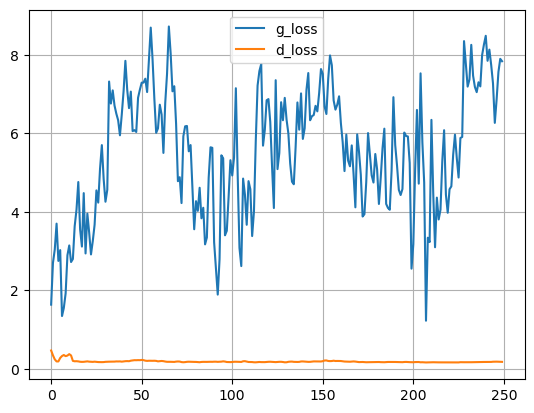

In [53]:
df = pd.DataFrame(hist)
df.plot(grid=True)
plt.show()


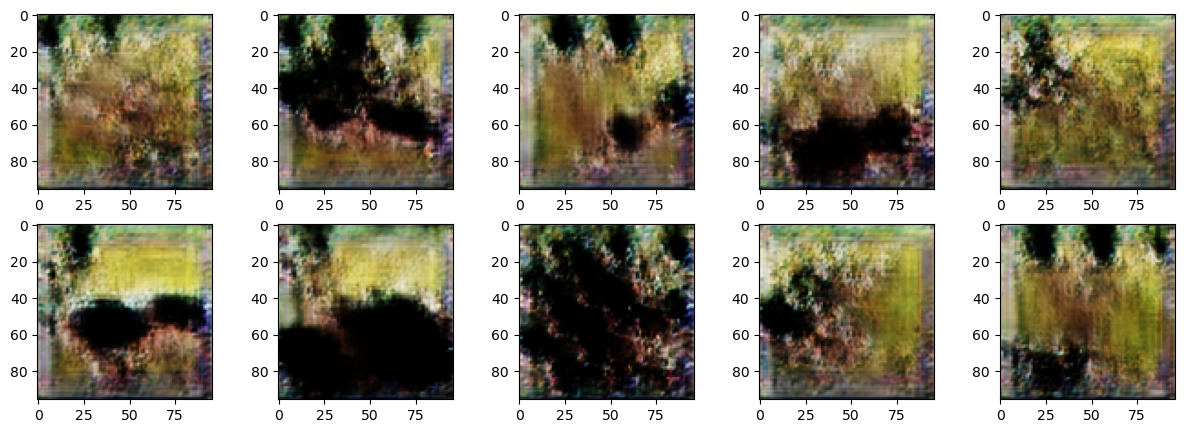

In [55]:
generator.eval()
with torch.no_grad():
  noise = torch.randn((10, generator.input_size)).to(device)
  generated_images = generator(noise)
  fig, axs = plt.subplots(2,5,figsize=(15,5))
  i = 0
  for ax in axs:
    for _ax in ax:
      img = generated_images[i].view(3, 96, 96).permute(1, 2, 0).cpu()
      img = (img + 1) / 2
      _ax.imshow(img.clamp(0, 1))
      i+=1
  plt.show()

En este caso, las imágenes producidas presentan una mejora notable en comparación con las generadas por la arquitectura simple, aunque todavía existe espacio para refinamientos adicionales.

## Resumen y Reflexión

En este análisis hemos explorado los fundamentos de las redes adversariales generativas (GANs), una clase extraordinaria de arquitecturas neuronales capaces de sintetizar datos realistas basándose en patrones del conjunto de entrenamiento, con énfasis en síntesis de imágenes. La estructura subyacente comprende dos agentes en competencia: el generador sintetiza imágenes a partir de vectores latentes de ruido, mientras que el discriminador intenta clasificar entre muestras auténticas del conjunto de datos y productos artificiales del generador. Una vez completado el entrenamiento, el discriminador se descarta y el generador se convierte en una herramienta versátil para crear imágenes sintéticas realistas. Estas arquitecturas encuentran aplicación en numerosos campos: síntesis de caras inexistentes, restauración y colorización de fotografías históricas, generación de objetos a partir de descripciones textuales, producción de videos sintéticos realistas, y la controvertida tecnología de videos deepfake, entre otros.